In [1]:
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from src.nn_modules.kan import KANLayer
from src.utils.datasets import EmbeddingDataset
from src.utils.global_constants import MODELS_DIR
from src.utils.train_test import (
    offline_train,
    mean_per_class_accuracy,
    measure_forward_backward_time,
)


# The random seed is fixed to ensure reproducibility of results
torch.manual_seed(42)
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
device

device(type='cpu')

In [2]:
# Create a directory for trained models if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

In [3]:
# Offline training parameters
batch_size = 256
learning_rate = 8e-4
criterion = nn.CrossEntropyLoss()
metric = mean_per_class_accuracy

# Loading training and testing datasets that contain precomputed elmbeddings
# generated by ResNet50 model
trainset = EmbeddingDataset("cub200_train_embed.pt")
testset = EmbeddingDataset("cub200_test_embed.pt")
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

### Baseline MLP

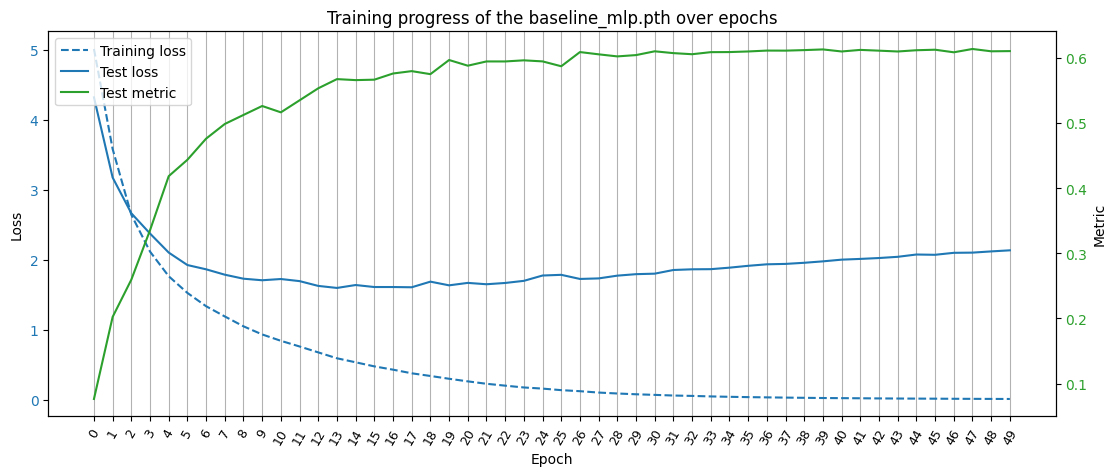

Early stopping is triggered at the epoch 49.
Best metric's value: 0.61308.
The model's weights are saved to /home/trxxxxkov/projects/spbu-bachelor-thesis/src/models/baseline_mlp.pth


In [4]:
class BaselineMLP(nn.Module):
    """Multi-Layer Perceptron model used as a reference for performance comparison

    This model is trained offline and serves as a baseline for evaluating the
    performance of proposed models trained in an online learning setting.
    """

    def __init__(
        self,
        input_dim: int = 2048,
        hidden_dim: int = 400,
        output_dim: int = 200,
        num_hidden_layers: int = 2,
    ):
        super().__init__()
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        return self.classifier(x)


mlp = BaselineMLP()
mlp_optimizer = torch.optim.NAdam(mlp.parameters(), lr=learning_rate)
# Perform offline training of the MLP baseline model with early stopping.
# The trained model's weights will be saved to the file `src/data/baseline_mlp.pth`.
offline_train(
    mlp, "baseline_mlp.pth", trainloader, testloader, criterion, metric, mlp_optimizer
)

In [5]:
forward, backward = measure_forward_backward_time(BaselineMLP, out_features=1024)
print("Forward/backward passes time benchmark for BaselineMLP:")
print(f"Forward pass time in miliseconds: {forward * 1000};")
print(f"Backward pass time in miliseconds: {backward * 1000};")

Backward pass: 100%|██████████| 100/100 [00:08<00:00, 11.23it/s]

Forward/backward passes time benchmark for BaselineMLP:
Forward pass time in miliseconds: 34.55478887000936;
Backward pass time in miliseconds: 54.56332209003449;


In [6]:
num_mlp_params = sum(p.numel() for p in mlp.parameters() if p.requires_grad)
print(f"Number of trainable parameters in BaselineMLP: {num_mlp_params}")

Number of trainable parameters in BaselineMLP: 1060200


### Baseline KAN

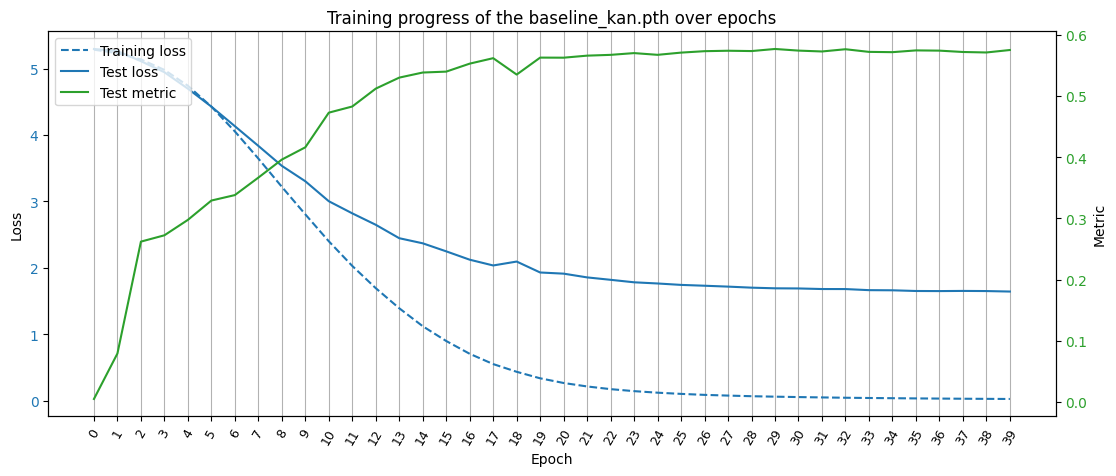

Early stopping is triggered at the epoch 39.
Best metric's value: 0.57693.
The model's weights are saved to /home/trxxxxkov/projects/spbu-bachelor-thesis/src/models/baseline_kan.pth


In [7]:
class BaselineKAN(nn.Module):
    """Kolmogorov-Arnold Network model used as a reference for performance comparison

    This model is trained offline and serves as a baseline for evaluating the
    performance of proposed models trained in an online learning setting.
    """

    def __init__(
        self,
        input_dim: int = 2048,
        hidden_dim: int = 200,
        output_dim: int = 200,
        num_hidden_layers: int = 1,
    ):
        super().__init__()
        layers = []
        layers.append(KANLayer(input_dim, hidden_dim))
        for _ in range(num_hidden_layers - 1):
            layers.append(KANLayer(hidden_dim, hidden_dim))
        layers.append(KANLayer(hidden_dim, output_dim))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        return self.classifier(x)


kan = BaselineKAN()
kan_optimizer = torch.optim.NAdam(kan.parameters(), lr=learning_rate)
# Perform offline training of the KAN baseline model with early stopping.
# The trained model's weights will be saved to the file `src/data/baseline_kan.pth`.
offline_train(
    kan, "baseline_kan.pth", trainloader, testloader, criterion, metric, kan_optimizer
)

In [8]:
forward, backward = measure_forward_backward_time(BaselineKAN, out_features=1024)
print("Forward/backward passes time benchmark for BaselineKAN:")
print(f"Forward pass time in miliseconds: {forward * 1000};")
print(f"Backward pass time in miliseconds: {backward * 1000};")

Backward pass: 100%|██████████| 100/100 [00:48<00:00,  2.07it/s]

Forward/backward passes time benchmark for BaselineKAN:
Forward pass time in miliseconds: 197.4821795400203;
Backward pass time in miliseconds: 266.5114977199846;


In [9]:
num_kan_params = sum(p.numel() for p in kan.parameters() if p.requires_grad)
print(f"Number of trainable parameters in BaselineKAN: {num_kan_params}")

Number of trainable parameters in BaselineKAN: 3151696
